# 🎯 LangGraph Supervisor Workflow - Simple Tutorial

## What You'll Learn

This notebook demonstrates a **Supervisor Agentic Workflow** using LangGraph and LangChain. 

### The Concept
A **supervisor** is like a project manager that:
1. **Receives** a user request
2. **Analyzes** what needs to be done
3. **Routes** the task to the right specialized agent
4. **Reviews** the results
5. **Decides** if the task is complete or needs more work

### Our Team
- 🌤️ **Weather Agent**: Gets weather information for cities
- 🐍 **Python Agent**: Executes Python code
- 👔 **Supervisor**: Orchestrates between agents and makes routing decisions

### How It Works
```
User Request → Supervisor → Weather Agent OR Python Agent → Supervisor → Final Answer
                    ↑___________________________________________|
```

The supervisor uses an LLM (Kimi K2.5) to intelligently decide which agent should handle each task!

## 1️⃣ Setup: Load Environment Variables

First, we load our API keys from the `.env` file. We need the Moonshot API key to use Kimi K2.5.

In [1]:
# Load environment variables from .env file
# We look in the parent directory (project root) for the .env file
from dotenv import load_dotenv
import os

# Construct path to .env file in parent directory
env_path = os.path.join(os.path.dirname(os.getcwd()), '.env')
load_dotenv(env_path)
print("✅ Loaded environment variables from .env file")

# Verify the Moonshot API key is loaded (don't print the actual key!)
moonshot_key = os.getenv("MOONSHOT_API_KEY")
if moonshot_key:
    print(f"✅ Moonshot API Key found: {moonshot_key[:10]}...")
else:
    raise ValueError("❌ MOONSHOT_API_KEY not found! Please add it to your .env file")

✅ Loaded environment variables from .env file
✅ Moonshot API Key found: sk-TuQTfwj...


## 2️⃣ Define State Schema for Agent Routing

**What is State?**
In LangGraph, the **state** is like a shared notebook that all agents can read and write to. It keeps track of:
- The conversation history (`messages`)
- Which agent should run next (`next_agent`)

**Why do we need a schema?**
The state schema defines the structure of our shared notebook. It tells LangGraph what fields to expect.

In [2]:
from typing import TypedDict, Annotated, Sequence, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
import operator

# Define our State schema using TypedDict
# This creates a structured "notebook" that all agents share
class AgentState(TypedDict):
    """
    State tracks the conversation and routing decisions.
    
    Fields:
    - messages: List of all messages in the conversation (accumulated using operator.add)
    - next_agent: Which agent the supervisor wants to run next ("weather", "python", or "finish")
    """
    # Annotated with operator.add means messages get APPENDED, not replaced
    messages: Annotated[Sequence[BaseMessage], operator.add]
    
    # The supervisor's routing decision
    next_agent: str

print("✅ State schema defined!")
print("   - messages: Stores conversation history")
print("   - next_agent: Tracks where to route next")

✅ State schema defined!
   - messages: Stores conversation history
   - next_agent: Tracks where to route next


## 3️⃣ Create the Weather Agent Node

The **Weather Agent** is a specialized worker that:
1. Receives a request from the supervisor
2. Extracts the city name from the conversation
3. Returns weather information

**Note**: For this demo, we'll simulate weather data. In production, you'd call a real weather API.

In [3]:
from langchain_core.tools import tool

# Define the weather tool using the @tool decorator
# This makes it easy for the LLM to understand and use
@tool
def get_weather(city: str) -> str:
    """
    Get the current weather for a city.
    
    Args:
        city: The name of the city (e.g., "San Francisco", "Tokyo", "Paris")
    
    Returns:
        A string describing the weather
    """
    # In production, you'd call a real weather API like OpenWeatherMap
    # For demo purposes, we return simulated data
    weather_conditions = {
        "sunny": "☀️ Sunny, 72°F (22°C)",
        "cloudy": "☁️ Cloudy, 65°F (18°C)", 
        "rainy": "🌧️ Rainy, 60°F (15°C)",
        "snowy": "❄️ Snowy, 32°F (0°C)"
    }
    
    # Simple logic to vary the "weather" based on city name length
    # (Just for demo - real implementation would use an API!)
    import hashlib
    hash_val = int(hashlib.md5(city.lower().encode()).hexdigest(), 16)
    conditions = list(weather_conditions.values())
    weather = conditions[hash_val % len(conditions)]
    
    return f"Weather in {city}: {weather}"

# Test the tool
print("✅ Weather tool created!")
print("\n🧪 Testing weather tool:")
print(get_weather.invoke("San Francisco"))
print(get_weather.invoke("Tokyo"))

✅ Weather tool created!

🧪 Testing weather tool:
Weather in San Francisco: ❄️ Snowy, 32°F (0°C)
Weather in Tokyo: 🌧️ Rainy, 60°F (15°C)


## 4️⃣ Create the Python Executor Agent Node

The **Python Agent** is another specialized worker that:
1. Receives a request to execute code
2. Runs the Python code safely
3. Returns the output

We use `PythonREPLTool` from LangChain which provides a sandboxed environment for code execution.

In [4]:
from langchain_experimental.tools import PythonREPLTool

# Create the Python execution tool
# PythonREPLTool provides a sandboxed Python environment
python_tool = PythonREPLTool()

# Test the Python tool
print("✅ Python execution tool created!")
print("\n🧪 Testing Python tool:")

# Test 1: Simple calculation
result1 = python_tool.invoke("print(2 + 2)")
print(f"2 + 2 = {result1}")

# Test 2: More complex calculation
result2 = python_tool.invoke("""
import math
fib = [0, 1]
for i in range(10):
    fib.append(fib[-1] + fib[-2])
print(f"First 12 Fibonacci numbers: {fib}")
""")
print(f"\nFibonacci result:\n{result2}")

/var/folders/1g/lz4110yd5_x6_lhf4pqkrphr0000gn/T/ipykernel_38774/4177564198.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonREPLTool
Python REPL can execute arbitrary code. Use with caution.


✅ Python execution tool created!

🧪 Testing Python tool:
2 + 2 = 4


Fibonacci result:
First 12 Fibonacci numbers: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89]



## 5️⃣ Implement the Supervisor Logic

This is the **brain** of our workflow! The supervisor:

1. **Reads** the conversation history from the state
2. **Analyzes** what the user is asking for
3. **Decides** which agent should handle it:
   - `"weather"` → Route to Weather Agent
   - `"python"` → Route to Python Agent  
   - `"finish"` → Task is complete, return final answer

The supervisor uses an LLM (Kimi K2.5) to make intelligent routing decisions based on the context.

In [5]:
# TROUBLESHOOTING VERSION - Uncomment sections one at a time to find the bottleneck

# from langchain_openai import ChatOpenAI
# from langgraph.types import Command
# from pydantic import BaseModel
# import requests

print("🔄 Starting troubleshooting...")

# === SECTION 1: Imports ===
print("\n[1/6] Testing imports...")
print("   Importing requests...")
import requests
print("   ✅ requests imported")
print("   Importing pydantic...")
from pydantic import BaseModel
print("   ✅ pydantic imported")
print("   Importing langgraph.types...")
from langgraph.types import Command
print("   ✅ langgraph.types imported")
print("   Importing langchain_openai...")
from langchain_openai import ChatOpenAI
print("   ✅ langchain_openai imported")
print("✅ All imports successful!")

# === SECTION 2: API Key Check ===
print("\n[2/6] Checking API key...")
import os
api_key = os.getenv("MOONSHOT_API_KEY")
if not api_key:
    raise ValueError("❌ MOONSHOT_API_KEY not found! Please check your .env file")
print(f"✅ API Key found: {api_key[:10]}...")

# === SECTION 3: API Connectivity Test ===
print("\n[3/6] Testing API connectivity (10 sec timeout)...")
try:
    response = requests.get(
        "https://api.moonshot.ai/v1/models",
        headers={"Authorization": f"Bearer {api_key}"},
        timeout=10
    )
    if response.status_code == 200:
        print(f"✅ API connection successful!")
    else:
        print(f"⚠️ API returned status {response.status_code}: {response.text[:100]}")
except Exception as e:
    print(f"❌ API connection failed: {e}")
    raise

# === SECTION 4: Initialize ChatOpenAI ===
print("\n[4/6] Initializing ChatOpenAI...")
llm = ChatOpenAI(
    model="kimi-k2.5",
    base_url="https://api.moonshot.ai/v1",
    api_key=api_key,
    temperature=1,  # Kimi K2.5 only supports temperature=1
    timeout=30,
    max_retries=2
)
print("✅ ChatOpenAI initialized")

# === SECTION 5: Define Structured Output Class ===
print("\n[5/6] Defining SupervisorDecision class...")
class SupervisorDecision(BaseModel):
    """The supervisor's routing decision"""
    reasoning: str
    next_agent: str  # Simplified for troubleshooting

print("✅ SupervisorDecision class defined")

# === SECTION 6: Create Structured Supervisor ===
print("\n[6/6] Creating structured supervisor...")
structured_supervisor = llm.with_structured_output(SupervisorDecision)
print("✅ Structured supervisor created")

print("\n" + "="*60)
print("🎉 ALL SECTIONS COMPLETED SUCCESSFULLY!")
print("="*60)

# Define the supervisor's system prompt (no code here, just a string)
SUPERVISOR_SYSTEM_PROMPT = """You are a Supervisor AI that routes user requests to the appropriate agent.

Available agents:
1. **weather** - Use for questions about weather
2. **python** - Use for calculations and code execution
3. **finish** - Use when task is complete

Provide your reasoning for the decision."""

🔄 Starting troubleshooting...

[1/6] Testing imports...
   Importing requests...
   ✅ requests imported
   Importing pydantic...
   ✅ pydantic imported
   Importing langgraph.types...


/Users/raymaldonado/Library/CloudStorage/GoogleDrive-vivachihuahua2004@gmail.com/My Drive/Code/oreilly-ai-agents/.venv/lib/python3.11/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


   ✅ langgraph.types imported
   Importing langchain_openai...
   ✅ langchain_openai imported
✅ All imports successful!

[2/6] Checking API key...
✅ API Key found: sk-TuQTfwj...

[3/6] Testing API connectivity (10 sec timeout)...
✅ API connection successful!

[4/6] Initializing ChatOpenAI...
✅ ChatOpenAI initialized

[5/6] Defining SupervisorDecision class...
✅ SupervisorDecision class defined

[6/6] Creating structured supervisor...
✅ Structured supervisor created

🎉 ALL SECTIONS COMPLETED SUCCESSFULLY!


In [45]:
# Define the Supervisor Node function
# This is called by LangGraph when it's the supervisor's turn

def supervisor_node(state: AgentState) -> Command[Literal["weather_agent", "python_agent", "__end__"]]:
    """
    The supervisor node analyzes the conversation and decides which agent to call next.
    Supports multi-step workflows by tracking which agents have already run.
    """
    print("\n" + "="*60)
    print("🤔 SUPERVISOR: Analyzing the request...")
    print("="*60)
    
    # Get the original user message (first human message)
    user_message = ""
    for msg in state["messages"]:
        if hasattr(msg, 'type') and msg.type == 'human':
            user_message = msg.content.lower()
            break
    
    # Track which agents we've already routed to (by looking at supervisor messages)
    agents_routed = set()
    supervisor_messages = []
    for msg in state["messages"]:
        if hasattr(msg, 'content') and hasattr(msg, 'type'):
            if msg.type == 'ai' and msg.content.startswith("[Supervisor]"):
                content_lower = msg.content.lower()
                supervisor_messages.append(msg.content[:100])
                # Check for explicit routing decisions - MUST use separate if statements
                # so both can be detected in different messages
                if "starting with weather" in content_lower or "routing to weather agent" in content_lower:
                    agents_routed.add("weather")
                if "now performing calculation" in content_lower or "routing to python agent" in content_lower:
                    agents_routed.add("python")
    
    # Check for agent responses (non-supervisor AI messages)
    agent_responses = []
    for msg in state["messages"]:
        if hasattr(msg, 'type') and msg.type == 'ai':
            content = msg.content if hasattr(msg, 'content') else ""
            if not content.startswith("[Supervisor]"):
                agent_responses.append(content)
                print(f"   Found agent response: {content[:60]}...")
        elif hasattr(msg, 'type'):
            print(f"   Message type: {msg.type}, content preview: {getattr(msg, 'content', 'N/A')[:40]}...")
    
    # Determine user intents from original query
    has_weather_intent = any(word in user_message for word in ["weather", "rain", "sunny", "cloudy", "snow", "forecast"])
    has_calc_intent = any(word in user_message for word in ["calculate", "computation", "code", "fibonacci", "°f", "°c", "celsius", "fahrenheit"])
    
    print(f"   Total messages in state: {len(state['messages'])}")
    print(f"   User query: {user_message[:80]}...")
    print(f"   Weather intent: {has_weather_intent}, Calc intent: {has_calc_intent}")
    print(f"   Agents already routed: {agents_routed}")
    print(f"   Agent responses count: {len(agent_responses)}")
    print(f"   Supervisor messages found: {len(supervisor_messages)}")
    for i, sm in enumerate(supervisor_messages[-3:]):  # Show last 3
        print(f"      [{i}] {sm}...")
    if agent_responses:
        print(f"   Last agent response preview: {agent_responses[-1][:100]}...")
    
    # MULTI-STEP HANDLING: If we have a response but haven't completed all intents
    print(f"   DEBUG: Checking multi-step condition: agent_responses={len(agent_responses)>0}, has_weather={has_weather_intent}, has_calc={has_calc_intent}")
    if agent_responses and has_weather_intent and has_calc_intent:
        # Multi-step task detected
        print(f"   DEBUG: Inside multi-step handling. weather in routed: {'weather' in agents_routed}, python in routed: {'python' in agents_routed}")
        if "weather" not in agents_routed:
            # Route to weather first
            print(f"\n📋 Decision: Multi-step task, routing to WEATHER first...")
            return Command(
                goto="weather_agent",
                update={
                    "messages": [AIMessage(content="[Supervisor] Routing to weather agent")],
                    "next_agent": "weather"
                }
            )
        elif "python" not in agents_routed:
            # Weather done, now do calculation
            print(f"\n📋 Decision: Weather complete, routing to PYTHON for calculation...")
            return Command(
                goto="python_agent",
                update={
                    "messages": [AIMessage(content="[Supervisor] Weather complete. Now performing calculation.")],
                    "next_agent": "python"
                }
            )
        else:
            # Both done, finish
            combined = " | ".join(agent_responses[-2:]) if len(agent_responses) >= 2 else agent_responses[-1]
            print(f"\n📋 Decision: Multi-step task complete!")
            return Command(
                goto="__end__",
                update={
                    "messages": [AIMessage(content=f"[Supervisor] Task complete. {combined[:200]}...")],
                    "next_agent": "finish"
                }
            )
    
    # SINGLE-STEP: If we have an agent response, finish
    if agent_responses:
        print(f"\n📋 Decision: Task complete")
        return Command(
            goto="__end__",
            update={
                "messages": [AIMessage(content=f"[Supervisor] Task complete. Answer: {agent_responses[-1][:200]}")],
                "next_agent": "finish"
            }
        )
    
    # INITIAL ROUTING: No agent response yet, decide where to go first
    # PRIORITY: Check user intents FIRST before LLM response parsing
    # This prevents LLM fluff words like "complete" from triggering early finish
    
    if has_weather_intent and has_calc_intent:
        # Multi-step: start with weather first
        next_agent = "weather"
        reasoning = "Multi-step task: starting with weather"
    elif has_weather_intent:
        next_agent = "weather"
        reasoning = "User asked about weather"
    elif has_calc_intent:
        next_agent = "python"
        reasoning = "User asked for calculation"
    else:
        # Fallback to LLM-based routing only if no clear intent detected
        messages = [SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT)] + list(state["messages"])
        response = llm.invoke(messages)
        response_text = response.content.lower()
        print(f"\n📋 LLM Response: {response.content[:150]}...")
        
        if "weather" in response_text:
            next_agent = "weather"
            reasoning = "Routing to weather agent"
        elif "python" in response_text or "code" in response_text or "calculate" in response_text:
            next_agent = "python"
            reasoning = "Routing to python agent"
        else:
            next_agent = "python"
            reasoning = "Defaulting to python agent"
    
    print(f"\n📋 Decision: {reasoning} -> {next_agent}")
    
    if next_agent == "weather":
        return Command(
            goto="weather_agent",
            update={
                "messages": [AIMessage(content=f"[Supervisor] {reasoning}")],
                "next_agent": "weather"
            }
        )
    elif next_agent == "python":
        return Command(
            goto="python_agent", 
            update={
                "messages": [AIMessage(content=f"[Supervisor] {reasoning}")],
                "next_agent": "python"
            }
        )
    else:
        return Command(
            goto="__end__",
            update={
                "messages": [AIMessage(content=f"[Supervisor] {reasoning}")],
                "next_agent": "finish"
            }
        )

print("✅ Supervisor node function defined!")
print("   - Analyzes conversation using LLM")
print("   - Returns Command with routing decision")
print("   - Updates state with reasoning")

✅ Supervisor node function defined!
   - Analyzes conversation using LLM
   - Returns Command with routing decision
   - Updates state with reasoning


## 6️⃣ Create the Worker Agent Nodes

Now we create the actual worker nodes that get called by the supervisor:
- **Weather Agent Node**: Calls the weather tool and reports back
- **Python Agent Node**: Calls the Python tool and reports back

Each worker:
1. Receives the current state
2. Uses a ReAct agent to process the request with tools
3. Returns results back to the supervisor

In [46]:
from langgraph.prebuilt import create_react_agent

def weather_agent_node(state: AgentState) -> Command[Literal["supervisor"]]:
    """
    The weather agent handles weather-related queries.
    
    This agent:
    1. Takes the user's request from the state
    2. Uses the get_weather tool to fetch weather data
    3. Returns the result back to the supervisor
    
    Args:
        state: Current conversation state
        
    Returns:
        Command: Always returns to supervisor with results
    """
    print("\n" + "-"*60)
    print("🌤️  WEATHER AGENT: Working on weather request...")
    print("-"*60)
    
    # Create a ReAct agent with the weather tool
    # ReAct = Reasoning + Acting (the agent thinks step-by-step)
    weather_agent = create_react_agent(
        model=llm,
        tools=[get_weather],
        state_modifier="You are a weather specialist. Use the get_weather tool to answer weather questions. Be concise."
    )
    
    # Invoke the agent with the current conversation
    # The agent will see all messages and decide to use the tool
    response = weather_agent.invoke(state)
    
    # Get the last message (the agent's response)
    agent_response = response["messages"][-1]
    
    print(f"\n✅ Weather Agent Result:")
    print(f"   {agent_response.content}")
    
    # Return to supervisor with the weather information
    return Command(
        goto="supervisor",
        update={
            "messages": [agent_response],
            "next_agent": "supervisor"
        }
    )


def python_agent_node(state: AgentState) -> Command[Literal["supervisor"]]:
    """
    The Python agent handles code execution requests.
    
    This agent:
    1. Takes the user's request from the state
    2. Uses the PythonREPLTool to execute code
    3. Returns the output back to the supervisor
    
    Args:
        state: Current conversation state
        
    Returns:
        Command: Always returns to supervisor with results
    """
    print("\n" + "-"*60)
    print("🐍 PYTHON AGENT: Executing code...")
    print("-"*60)
    
    # Create a ReAct agent with the Python tool
    python_agent = create_react_agent(
        model=llm,
        tools=[python_tool],
        state_modifier="You are a Python expert. Use the python tool to execute code and answer calculation questions. Always print your results."
    )
    
    # Invoke the agent with the current conversation
    response = python_agent.invoke(state)
    
    # Get the last message
    agent_response = response["messages"][-1]
    
    print(f"\n✅ Python Agent Result:")
    print(f"   {agent_response.content[:200]}..." if len(agent_response.content) > 200 else f"   {agent_response.content}")
    
    # Return to supervisor with the execution results
    return Command(
        goto="supervisor",
        update={
            "messages": [agent_response],
            "next_agent": "supervisor"
        }
    )

print("✅ Worker agent nodes defined!")
print("   - weather_agent_node: Handles weather queries")
print("   - python_agent_node: Handles code execution")
print("   - Both return to supervisor when done")

✅ Worker agent nodes defined!
   - weather_agent_node: Handles weather queries
   - python_agent_node: Handles code execution
   - Both return to supervisor when done


## 7️⃣ Build the LangGraph Workflow

Now we assemble all the pieces into a complete graph:

1. **Create StateGraph**: Uses our AgentState schema
2. **Add Nodes**: supervisor, weather_agent, python_agent
3. **Add Edges**: Define the flow between nodes
4. **Compile**: Create the executable workflow

The graph structure:
```
START → supervisor → (weather_agent OR python_agent) → supervisor → END
                ↑______________________________________|
```

In [47]:
from langgraph.graph import StateGraph, START, END

# Step 1: Create the StateGraph
# This defines the structure of our workflow
workflow = StateGraph(AgentState)

# Step 2: Add all nodes to the graph
# Each node is a function that processes the state
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("weather_agent", weather_agent_node)
workflow.add_node("python_agent", python_agent_node)

# Step 3: Define the entry point
# All workflows start at the supervisor
workflow.add_edge(START, "supervisor")

# Step 4: Compile the graph
# This creates the executable workflow
supervisor_app = workflow.compile()

print("✅ Workflow compiled successfully!")
print("\n📊 Graph Structure:")
print("   START → supervisor")
print("              ↓")
print("    ┌──── weather_agent")
print("    │         ↓")
print("    └──── python_agent")
print("              ↓")
print("         supervisor → END")

✅ Workflow compiled successfully!

📊 Graph Structure:
   START → supervisor
              ↓
    ┌──── weather_agent
    │         ↓
    └──── python_agent
              ↓
         supervisor → END


## 8️⃣ Visualize the Graph

Let's see what our workflow looks like! LangGraph can generate a visual diagram.

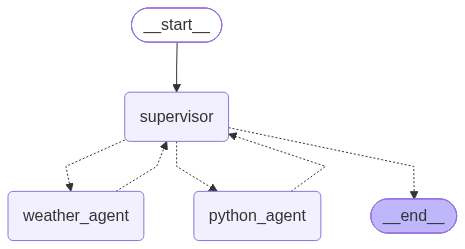

✅ Graph visualization generated!


In [48]:
# Visualize the workflow as a diagram
from IPython.display import Image, display

try:
    # Try to generate a PNG image
    png_data = supervisor_app.get_graph().draw_mermaid_png()
    display(Image(png_data))
    print("✅ Graph visualization generated!")
except Exception as e:
    # Fallback to ASCII art if PNG generation fails
    print("⚠️ Could not generate PNG, showing ASCII diagram:")
    print(supervisor_app.get_graph().draw_ascii())

## 9️⃣ Test the Supervisor Workflow

Now let's run some examples to see the supervisor in action!

### Example 1: Weather Query
The supervisor should route this to the weather agent.

In [49]:
# Example 1: Weather Query
print("🧪 EXAMPLE 1: Weather Query")
print("="*60)
print("User: 'What's the weather like in Tokyo?'")
print("="*60)

# Initialize the state with the user's question
initial_state = {
    "messages": [HumanMessage(content="What's the weather like in Tokyo?")],
    "next_agent": ""
}

# Stream through the workflow
# This lets us see each step as it happens
for event in supervisor_app.stream(initial_state, stream_mode="values"):
    # Just printing the final message from each step
    if event["messages"]:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, 'content') and last_msg.content:
            # Only print substantial messages (not empty ones)
            if len(last_msg.content) > 5:
                print(f"\n💬 {last_msg.type.upper()}: {last_msg.content[:150]}...")

print("\n" + "="*60)
print("✅ Example 1 Complete!")

🧪 EXAMPLE 1: Weather Query
User: 'What's the weather like in Tokyo?'

💬 HUMAN: What's the weather like in Tokyo?...

🤔 SUPERVISOR: Analyzing the request...
   Message type: human, content preview: What's the weather like in Tokyo?...
   Total messages in state: 1
   User query: what's the weather like in tokyo?...
   Weather intent: True, Calc intent: False
   Agents already routed: set()
   Agent responses count: 0
   Supervisor messages found: 0
   DEBUG: Checking multi-step condition: agent_responses=False, has_weather=True, has_calc=False

📋 Decision: User asked about weather -> weather

💬 AI: [Supervisor] User asked about weather...

------------------------------------------------------------
🌤️  WEATHER AGENT: Working on weather request...
------------------------------------------------------------

✅ Weather Agent Result:
   Currently in Tokyo: 🌧️ Rainy, 60°F (15°C)

💬 AI: Currently in Tokyo: 🌧️ Rainy, 60°F (15°C)...

🤔 SUPERVISOR: Analyzing the request...
   Message type: hum

### Example 2: Python Calculation
The supervisor should route this to the Python agent.

In [50]:
# Example 2: Python Calculation
print("\n\n🧪 EXAMPLE 2: Python Calculation")
print("="*60)
print("User: 'Calculate the first 10 Fibonacci numbers'")
print("="*60)

initial_state = {
    "messages": [HumanMessage(content="Calculate the first 10 Fibonacci numbers")],
    "next_agent": ""
}

for event in supervisor_app.stream(initial_state, stream_mode="values"):
    if event["messages"]:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, 'content') and last_msg.content:
            if len(last_msg.content) > 5:
                print(f"\n💬 {last_msg.type.upper()}: {last_msg.content[:200]}...")

print("\n" + "="*60)
print("✅ Example 2 Complete!")



🧪 EXAMPLE 2: Python Calculation
User: 'Calculate the first 10 Fibonacci numbers'

💬 HUMAN: Calculate the first 10 Fibonacci numbers...

🤔 SUPERVISOR: Analyzing the request...
   Message type: human, content preview: Calculate the first 10 Fibonacci numbers...
   Total messages in state: 1
   User query: calculate the first 10 fibonacci numbers...
   Weather intent: False, Calc intent: True
   Agents already routed: set()
   Agent responses count: 0
   Supervisor messages found: 0
   DEBUG: Checking multi-step condition: agent_responses=False, has_weather=False, has_calc=True

📋 Decision: User asked for calculation -> python

💬 AI: [Supervisor] User asked for calculation...

------------------------------------------------------------
🐍 PYTHON AGENT: Executing code...
------------------------------------------------------------

✅ Python Agent Result:
   Here are the first 10 Fibonacci numbers:

| n | F(n) |
|---|------|
| 1 | 0 |
| 2 | 1 |
| 3 | 1 |
| 4 | 2 |
| 5 | 3 |
| 6 | 5 |
| 7 

### Example 3: Multi-Step Task

This example shows how the supervisor can handle a task that requires BOTH agents:
1. First, get the weather
2. Then, use Python to analyze or format the result

Watch how the supervisor routes between agents!

In [51]:
# Example 3: Multi-Step Task
print("\n\n🧪 EXAMPLE 3: Multi-Step Task")
print("="*60)
print("User: 'Get the weather in Paris, then calculate what 72°F is in Celsius'")
print("="*60)

initial_state = {
    "messages": [HumanMessage(content="Get the weather in Paris, then calculate what 72°F is in Celsius")],
    "next_agent": ""
}

for event in supervisor_app.stream(initial_state, stream_mode="values"):
    if event["messages"]:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, 'content') and last_msg.content:
            if len(last_msg.content) > 5:
                print(f"\n💬 {last_msg.type.upper()}: {last_msg.content[:200]}...")

print("\n" + "="*60)
print("✅ Example 3 Complete!")



🧪 EXAMPLE 3: Multi-Step Task
User: 'Get the weather in Paris, then calculate what 72°F is in Celsius'

💬 HUMAN: Get the weather in Paris, then calculate what 72°F is in Celsius...

🤔 SUPERVISOR: Analyzing the request...
   Message type: human, content preview: Get the weather in Paris, then calculate...
   Total messages in state: 1
   User query: get the weather in paris, then calculate what 72°f is in celsius...
   Weather intent: True, Calc intent: True
   Agents already routed: set()
   Agent responses count: 0
   Supervisor messages found: 0
   DEBUG: Checking multi-step condition: agent_responses=False, has_weather=True, has_calc=True

📋 Decision: Multi-step task: starting with weather -> weather

💬 AI: [Supervisor] Multi-step task: starting with weather...

------------------------------------------------------------
🌤️  WEATHER AGENT: Working on weather request...
------------------------------------------------------------

✅ Weather Agent Result:
   Weather in Paris: ☀️ Sun

## 🔍 Complete Trace Example

Let's run one more example with detailed output showing every step of the workflow.

In [52]:
# Detailed trace with step-by-step output
def run_with_trace(user_message: str):
    """
    Run the workflow with detailed step-by-step output.
    """
    print("\n" + "="*70)
    print(f"🚀 NEW REQUEST: {user_message}")
    print("="*70)
    
    initial_state = {
        "messages": [HumanMessage(content=user_message)],
        "next_agent": ""
    }
    
    step = 0
    for event in supervisor_app.stream(initial_state, stream_mode="values"):
        step += 1
        print(f"\n📍 STEP {step}")
        print("-" * 70)
        
        # Show all messages in this step
        for msg in event["messages"]:
            if hasattr(msg, 'content') and msg.content:
                msg_type = msg.type.upper()
                content = msg.content[:300] + "..." if len(msg.content) > 300 else msg.content
                print(f"\n{msg_type}:")
                for line in content.split('\n'):
                    print(f"   {line}")
    
    print("\n" + "="*70)
    print("🏁 WORKFLOW COMPLETE")
    print("="*70)
    
    # Return final answer
    return event["messages"][-1].content if event["messages"] else "No response"

# Run with a simple weather query
final_answer = run_with_trace("What's the weather in San Francisco?")
print(f"\n📢 FINAL ANSWER:\n{final_answer}")


🚀 NEW REQUEST: What's the weather in San Francisco?

📍 STEP 1
----------------------------------------------------------------------

HUMAN:
   What's the weather in San Francisco?

🤔 SUPERVISOR: Analyzing the request...
   Message type: human, content preview: What's the weather in San Francisco?...
   Total messages in state: 1
   User query: what's the weather in san francisco?...
   Weather intent: True, Calc intent: False
   Agents already routed: set()
   Agent responses count: 0
   Supervisor messages found: 0
   DEBUG: Checking multi-step condition: agent_responses=False, has_weather=True, has_calc=False

📋 Decision: User asked about weather -> weather

📍 STEP 2
----------------------------------------------------------------------

HUMAN:
   What's the weather in San Francisco?

AI:
   [Supervisor] User asked about weather

------------------------------------------------------------
🌤️  WEATHER AGENT: Working on weather request...
--------------------------------------------

## 📚 Summary

### What We Built

We created a **Supervisor Workflow** with three components:

1. **Supervisor** 👔
   - Uses Kimi K2.5 to analyze requests
   - Makes routing decisions using structured output
   - Decides: weather → python → finish

2. **Weather Agent** 🌤️
   - Specialized for weather queries
   - Uses the `get_weather` tool
   - Returns results to supervisor

3. **Python Agent** 🐍
   - Specialized for code execution
   - Uses `PythonREPLTool`
   - Returns results to supervisor

### How It Works

```
┌─────────────┐     ┌─────────────┐     ┌─────────────┐
│    START    │────▶│  SUPERVISOR │────▶│   WEATHER   │
└─────────────┘     │             │◄────│   AGENT     │
                    │  (Router)   │     └─────────────┘
                    │             │     ┌─────────────┐
                    │             │────▶│   PYTHON    │
                    │             │◄────│   AGENT     │
                    └──────┬──────┘     └─────────────┘
                           │
                           ▼
                    ┌─────────────┐
                    │     END     │
                    └─────────────┘
```

### Key Concepts

- **State**: Shared data structure all agents read/write
- **Command**: Tells LangGraph where to go next
- **Structured Output**: Ensures consistent routing decisions
- **ReAct Agents**: Worker agents that reason and act

### Try It Yourself!

Modify the examples above or try:
- "What's the weather in London and what is 25 * 4?"
- "Calculate the area of a circle with radius 5"
- "Get weather for Tokyo, then convert the temperature to Celsius"

In [53]:
# Example 3: Multi-Step Task
print("\n\n🧪 EXAMPLE 3: Multi-Step Task")
print("="*60)
print("="*60)

initial_state = {
    "messages": [HumanMessage(content="Get the weather in Chihuahua, Mexico, then create a couple of palindrome sentences and test them in Python to see if they are or not palindromes.")],
    "next_agent": ""
}

for event in supervisor_app.stream(initial_state, stream_mode="values"):
    if event["messages"]:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, 'content') and last_msg.content:
            if len(last_msg.content) > 5:
                print(f"\n💬 {last_msg.type.upper()}: {last_msg.content[:200]}...")

print("\n" + "="*60)
print("✅ Example 3 Complete!")



🧪 EXAMPLE 3: Multi-Step Task

💬 HUMAN: Get the weather in Chihuahua, Mexico, then create a couple of palindrome sentences and test them in Python to see if they are or not palindromes....

🤔 SUPERVISOR: Analyzing the request...
   Message type: human, content preview: Get the weather in Chihuahua, Mexico, th...
   Total messages in state: 1
   User query: get the weather in chihuahua, mexico, then create a couple of palindrome sentenc...
   Weather intent: True, Calc intent: False
   Agents already routed: set()
   Agent responses count: 0
   Supervisor messages found: 0
   DEBUG: Checking multi-step condition: agent_responses=False, has_weather=True, has_calc=False

📋 Decision: User asked about weather -> weather

💬 AI: [Supervisor] User asked about weather...

------------------------------------------------------------
🌤️  WEATHER AGENT: Working on weather request...
------------------------------------------------------------

✅ Weather Agent Result:
   The weather in Chihuahua, 